# Finite element method demos
First: 1-D diffusion, constant coefficient, Dirichlet BCs

In [23]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# FEM solver for d²T/dx² + f = 0 where f = 50 exp(x)
#
# Boundary conditions
#   T(-1) = 100 and T(1) = 100

nElem = 5
x = np.linspace(-1.0, 1.0, nElem + 1)

K = np.zeros((nElem + 1, nElem + 1))
F = np.zeros(nElem + 1)

In [25]:
for elem in range(nElem):
    n1 = elem
    n2 = elem + 1

    x1 = x[n1]
    x2 = x[n2]
    dx = x2 - x1

    # Stiffness contributions
    K[n1, n1] -= 1 / dx
    K[n1, n2] += 1 / dx
    K[n2, n1] += 1 / dx
    K[n2, n2] -= 1 / dx

    # Forcing contributions
    F[n1] -= 50 * (np.exp(x2) - x2 * np.exp(x1) + x1 * np.exp(x1) - np.exp(x1)) / dx
    F[n2] -= 50 * (x2 * np.exp(x2) - np.exp(x2) - x1 * np.exp(x2) + np.exp(x1)) / dx

In [26]:
# Left boundary: x = -1
n1 = 0
K[n1, :] = 0.0
K[n1, n1] = 1.0
F[n1] = 100.0

# Right boundary: x = 1
n1 = nElem
K[n1, :] = 0.0
K[n1, n1] = 1.0
F[n1] = 100.0

In [27]:
# solve
T = np.linalg.solve(K, F)

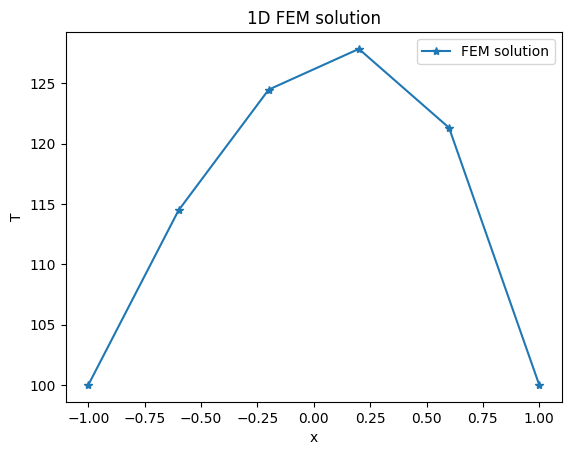

In [28]:
plt.figure()
plt.plot(x, T, marker='*', linewidth=1.5, label='FEM solution')
plt.xlabel('x')
plt.ylabel('T')
plt.title('1D FEM solution')
plt.legend()
plt.show()

In [29]:
# For the exact solution, use a finer grid for smooth plotting.
Npt = 20 * nElem + 1
xe = np.linspace(-1.0, 1.0, Npt)

Te = -50 * np.exp(xe) + 50 * xe * np.sinh(1) + 100 + 50 * np.cosh(1)

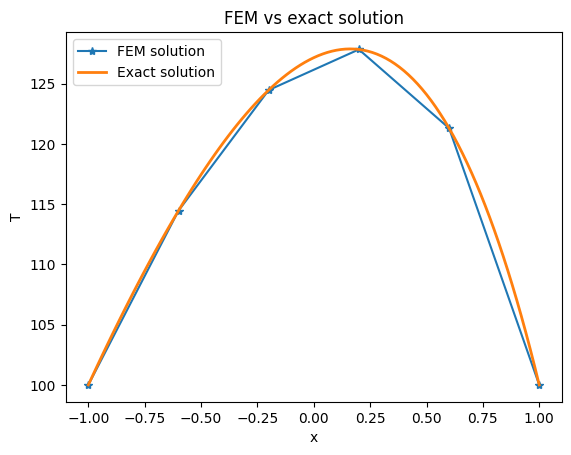

In [30]:
plt.figure()
plt.plot(x, T, marker='*', linewidth=1.5, label='FEM solution')
plt.plot(xe, Te, linewidth=2, label='Exact solution')
plt.xlabel('x')
plt.ylabel('T')
plt.title('FEM vs exact solution')
plt.legend()
plt.show()

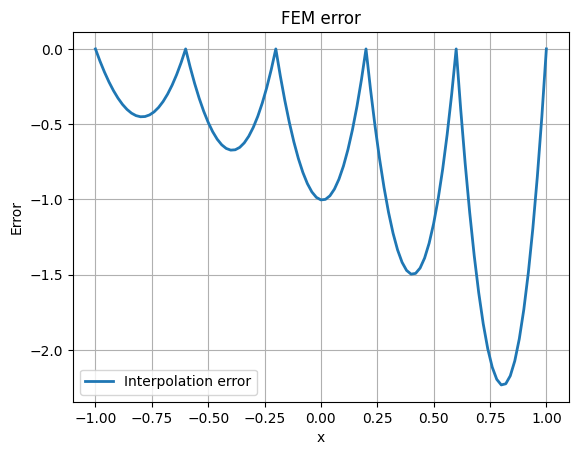

In [31]:
# compare exact and approximate solutions

Terr = np.zeros(Npt)
Terr[0] = T[0] - Te[0]

h = x[1] - x[0]

for i in range(1, Npt - 1):
    xxi = xe[i]
    Tei = Te[i]

    j = int(np.floor((xxi - xe[0]) / h))
    j = min(j, nElem - 1)  # protect against roundoff near the right boundary

    x0 = x[j]
    x1v = x[j + 1]
    T0 = T[j]
    T1 = T[j + 1]

    xi = 2 * (xxi - x0) / (x1v - x0) - 1
    Ti = 0.5 * (1 - xi) * T0 + 0.5 * (1 + xi) * T1

    Terr[i] = Ti - Tei

Terr[-1] = T[-1] - Te[-1]

plt.figure()
plt.plot(xe, Terr, linewidth=2, label='Interpolation error')
plt.xlabel('x')
plt.ylabel('Error')
plt.title('FEM error')
plt.legend()
plt.grid(True)
plt.show()

## Neumann boundary condition on the right

Same PDE $k\,T_{xx} + f = 0$ with $k=1$ and $f(x) = 50 e^x$. Keep **Dirichlet** on the left,
$T(-1) = 100$, and apply a **Neumann** BC on the right:

$$-k\,T_x(1) = q_{\text{right}}.$$

The weighted residual for the last node $i = N+1$ is

$$R_{N+1} = \left.\bigl(\phi_{N+1}\,k\,\tilde{T}_x\bigr)\right|_{x=x_{N+1}}
- \int_{x_N}^{x_{N+1}} \phi_{{N+1}_x}\,k\,\tilde{T}_x\,dx
+ \int_{x_N}^{x_{N+1}} \phi_{N+1}\,f\,dx.$$

Substituting $-k\,\tilde{T}_x = q_{\text{right}}$ into the boundary term gives

$$R_{N+1} = -\phi_{N+1}(x_{N+1})\,q_{\text{right}}
- \int_{x_N}^{x_{N+1}} \phi_{{N+1}_x}\,k\,\tilde{T}_x\,dx
+ \int_{x_N}^{x_{N+1}} \phi_{N+1}\,f\,dx.$$

The boundary term $-\phi_{N+1}(x_{N+1})\,q_{\text{right}}$ does **not** depend on the
temperature, so the Neumann BC does **not** change the stiffness matrix — it only adds
$q_{\text{right}}$ to the last entry of the load vector:

```python
F[nElem] += qright
```

The forcing integrals are evaluated with **Gaussian quadrature** (matching the MATLAB reference code).

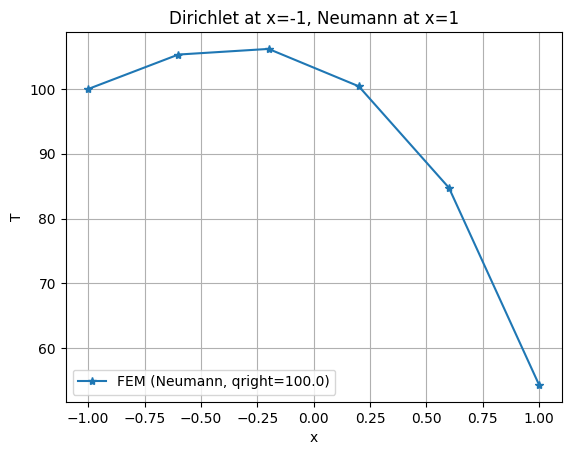

T(-1) = 100.000000  (enforced = 100)
T(1)  = 54.304389  (free, determined by the solve)


In [34]:
# FEM solver for k d²T/dx² + f = 0 where f = 50 exp(x), k = 1.
#
# BCs:
#   x = -1 : T(-1) = 100      (Dirichlet)
#   x =  1 : dT/dx = qright   (Neumann, "specified heat transfer")
#
# Forcing integral evaluated with Gaussian quadrature.
# (Direct Python port of the provided MATLAB code, RightBC = 0.)

nElem = 5
xN = np.linspace(-1.0, 1.0, nElem + 1)

# --- right BC: Neumann ---
qright = 100.0   # try e.g. qright = 20.0

# --- Gaussian quadrature rule ---
Nq = 2
if Nq == 1:
    alphaq = np.array([2.0])
    xiq    = np.array([0.0])
elif Nq == 2:
    alphaq = np.array([1.0, 1.0])
    xiq    = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
else:
    raise ValueError(f"Unknown quadrature rule (Nq = {Nq})")

KN = np.zeros((nElem + 1, nElem + 1))
FN = np.zeros(nElem + 1)

# --- element assembly ---
for elem in range(nElem):
    n1 = elem
    n2 = elem + 1

    x1 = xN[n1]
    x2 = xN[n2]
    dx = x2 - x1

    # stiffness contributions
    KN[n1, n1] -= 1 / dx
    KN[n1, n2] += 1 / dx
    KN[n2, n1] += 1 / dx
    KN[n2, n2] -= 1 / dx

    # forcing via Gaussian quadrature
    for nn in range(Nq):
        xi = xiq[nn]
        xq = x1 + 0.5 * (1 + xi) * dx
        f  = 50 * np.exp(xq)

        phi1 = 0.5 * (1 - xi)
        phi2 = 0.5 * (1 + xi)

        FN[n1] -= alphaq[nn] * 0.5 * phi1 * f * dx
        FN[n2] -= alphaq[nn] * 0.5 * phi2 * f * dx

# --- left Dirichlet: T(-1) = 100 (row replacement) ---
nL = 0
KN[nL, :] = 0.0
KN[nL, nL] = 1.0
FN[nL] = 100.0

# --- right Neumann: add qright to the load vector (natural BC) ---
nR = nElem
FN[nR] += qright

# --- solve and plot ---
TN = np.linalg.solve(KN, FN)

plt.figure()
plt.plot(xN, TN, marker='*', linewidth=1.5, label=f'FEM (Neumann, qright={qright})')
plt.xlabel('x')
plt.ylabel('T')
plt.title("Dirichlet at x=-1, Neumann at x=1")
plt.legend()
plt.grid(True)
plt.show()

print(f"T(-1) = {TN[0]:.6f}  (enforced = 100)")
print(f"T(1)  = {TN[-1]:.6f}  (free, determined by the solve)")

## Robin (convection) boundary condition on the right

Keep **Dirichlet** on the left, $T(-1) = 100$, and apply a **Robin** (convective) BC on the right:

$$-k\,T_x(1) = h_{\text{ext}}\bigl[T_{\text{ext}} - T(1)\bigr].$$

Following the same approach as the Neumann case, the weighted residual for $i = N+1$ is

$$R_{N+1} = \left.\bigl(\phi_{N+1}\,k\,\tilde{T}_x\bigr)\right|_{x=x_{N+1}}
- \int_{x_N}^{x_{N+1}} \phi_{{N+1}_x}\,k\,\tilde{T}_x\,dx
+ \int_{x_N}^{x_{N+1}} \phi_{N+1}\,f\,dx.$$

Substituting $-k\,\tilde{T}_x = h_{\text{ext}}\bigl[T_{\text{ext}} - \tilde{T}(x_{N+1})\bigr]$ into the boundary term gives

$$R_{N+1} = -\phi_{N+1}(x_{N+1})\,h_{\text{ext}}\bigl[T_{\text{ext}} - \tilde{T}(x_{N+1})\bigr]
- \int_{x_N}^{x_{N+1}} \phi_{{N+1}_x}\,k\,\tilde{T}_x\,dx
+ \int_{x_N}^{x_{N+1}} \phi_{N+1}\,f\,dx.$$

Unlike the Neumann case, the Robin BC **does** introduce a new dependence on the solution
through $\tilde{T}(x_{N+1})$. This modifies both the stiffness matrix and the load vector:

```python
K[nElem, nElem] += hext      # stiffness contribution from T(x_{N+1})
F[nElem]        += hext * Text   # load contribution from T_ext
```

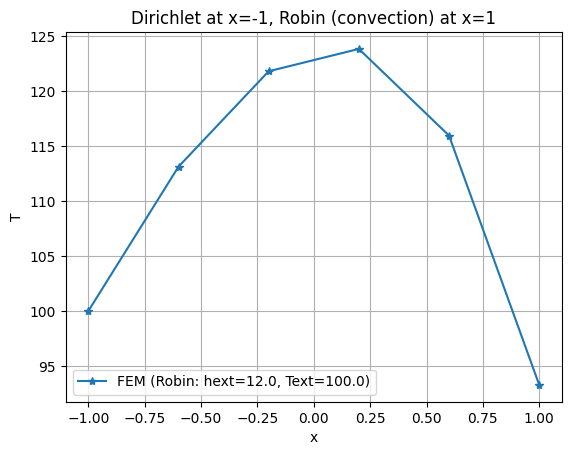

T(-1) = 100.000000  (enforced = 100)
T(1)  = 93.291114  (free)
-dT/dx|_{x=1} ≈ 56.6157,   hext*(Text - T(1)) = 80.5066


In [35]:
# Same FEM solver but with a Robin (convection) BC on the right:
#   -k dT/dx |_{x=1} = hext * (Text - T(1))
# Left BC still Dirichlet: T(-1) = 100.
# (Direct Python port of the provided MATLAB code, RightBC = 1.)

nElem = 5
xR = np.linspace(-1.0, 1.0, nElem + 1)

# --- right BC: Robin / convection ---
hext = 12.0
Text = 100.0

# --- Gaussian quadrature rule (Nq = 2) ---
Nq = 2
alphaq = np.array([1.0, 1.0])
xiq    = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])

KR = np.zeros((nElem + 1, nElem + 1))
FR = np.zeros(nElem + 1)

# --- element assembly (identical to the Neumann case) ---
for elem in range(nElem):
    n1 = elem
    n2 = elem + 1

    x1 = xR[n1]
    x2 = xR[n2]
    dx = x2 - x1

    KR[n1, n1] -= 1 / dx
    KR[n1, n2] += 1 / dx
    KR[n2, n1] += 1 / dx
    KR[n2, n2] -= 1 / dx

    for nn in range(Nq):
        xi = xiq[nn]
        xq = x1 + 0.5 * (1 + xi) * dx
        f  = 50 * np.exp(xq)

        phi1 = 0.5 * (1 - xi)
        phi2 = 0.5 * (1 + xi)

        FR[n1] -= alphaq[nn] * 0.5 * phi1 * f * dx
        FR[n2] -= alphaq[nn] * 0.5 * phi2 * f * dx

# --- left Dirichlet: T(-1) = 100 ---
nL = 0
KR[nL, :] = 0.0
KR[nL, nL] = 1.0
FR[nL] = 100.0

# --- right Robin: adds to both K and F ---
nR = nElem
KR[nR, nR] += hext
FR[nR]    += hext * Text

# --- solve and plot ---
TR_sol = np.linalg.solve(KR, FR)

plt.figure()
plt.plot(xR, TR_sol, marker='*', linewidth=1.5,
         label=f'FEM (Robin: hext={hext}, Text={Text})')
plt.xlabel('x')
plt.ylabel('T')
plt.title("Dirichlet at x=-1, Robin (convection) at x=1")
plt.legend()
plt.grid(True)
plt.show()

# Check the Robin condition numerically:
# -dT/dx |_{x=1} ≈ -(T[-1] - T[-2]) / dx   (one-sided difference)
dx_last = xR[-1] - xR[-2]
dTdx_right = (TR_sol[-1] - TR_sol[-2]) / dx_last
lhs = -dTdx_right
rhs = hext * (Text - TR_sol[-1])
print(f"T(-1) = {TR_sol[0]:.6f}  (enforced = 100)")
print(f"T(1)  = {TR_sol[-1]:.6f}  (free)")
print(f"-dT/dx|_{{x=1}} ≈ {lhs:.4f},   hext*(Text - T(1)) = {rhs:.4f}")

## Error vs number of elements (Dirichlet / Neumann / Robin)

This section increases the element count and computes FEM error for each boundary-condition type separately.

For each case, we solve on a mesh with `nElem` elements, interpolate the FEM solution onto a fine grid,
and compare with the corresponding exact solution. The plotted error is the max norm
$\|T_h - T_{\text{exact}}\|_{\infty}$ on the fine grid.

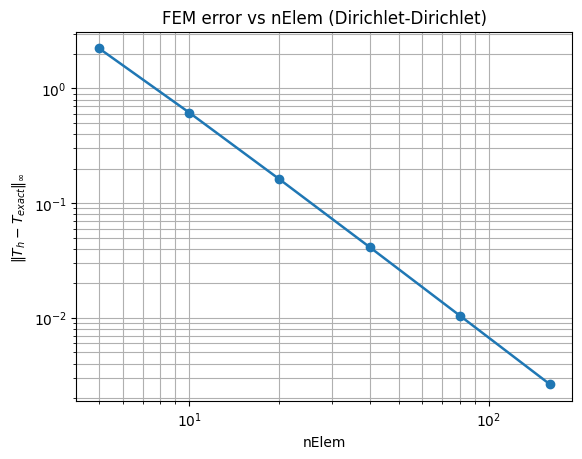

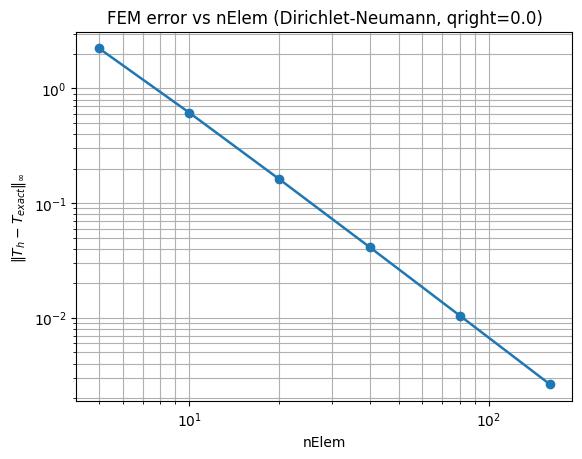

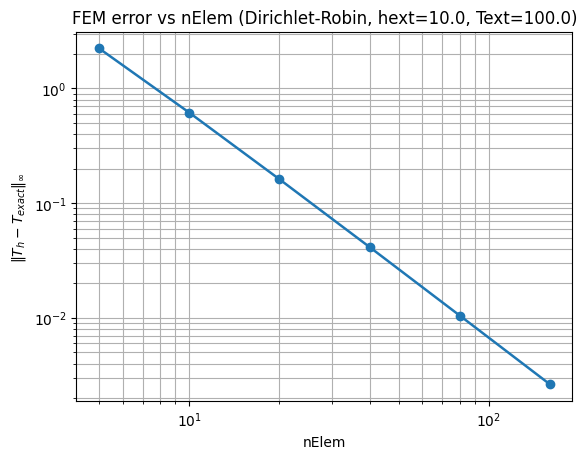

nElem: [  5  10  20  40  80 160]
Dirichlet errors: [2.23526185 0.61557225 0.16163889 0.04142645 0.01047187 0.00263414]
Neumann errors: [2.23858144 0.61579178 0.16165298 0.04142735 0.01047192 0.00263414]
Robin errors: [2.23508713 0.61556069 0.16163815 0.04142641 0.01047187 0.00263414]


In [36]:
# Convergence/error study for increasing nElem with separate plots for
# 1) Dirichlet-Dirichlet, 2) Dirichlet-Neumann, 3) Dirichlet-Robin.

import numpy as np
import matplotlib.pyplot as plt


def build_system(n_elem, bc_type, qright=0.0, hext=10.0, text=100.0):
    """Assemble K,F for k*T_xx + f = 0, k=1, f=50*exp(x), with left Dirichlet T(-1)=100."""
    x = np.linspace(-1.0, 1.0, n_elem + 1)
    K = np.zeros((n_elem + 1, n_elem + 1))
    F = np.zeros(n_elem + 1)

    # 2-point Gauss rule
    alphaq = np.array([1.0, 1.0])
    xiq = np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])

    for elem in range(n_elem):
        n1 = elem
        n2 = elem + 1
        x1 = x[n1]
        x2 = x[n2]
        dx = x2 - x1

        # stiffness
        K[n1, n1] -= 1.0 / dx
        K[n1, n2] += 1.0 / dx
        K[n2, n1] += 1.0 / dx
        K[n2, n2] -= 1.0 / dx

        # forcing by quadrature
        for nn in range(2):
            xi = xiq[nn]
            xq = x1 + 0.5 * (1.0 + xi) * dx
            f = 50.0 * np.exp(xq)
            phi1 = 0.5 * (1.0 - xi)
            phi2 = 0.5 * (1.0 + xi)
            F[n1] -= alphaq[nn] * 0.5 * phi1 * f * dx
            F[n2] -= alphaq[nn] * 0.5 * phi2 * f * dx

    # Left Dirichlet: T(-1) = 100
    K[0, :] = 0.0
    K[0, 0] = 1.0
    F[0] = 100.0

    # Right boundary condition
    nR = n_elem
    if bc_type == "dirichlet":
        K[nR, :] = 0.0
        K[nR, nR] = 1.0
        F[nR] = 100.0
    elif bc_type == "neumann":
        # -T_x(1) = qright  -> natural load contribution
        F[nR] += qright
    elif bc_type == "robin":
        # -T_x(1) = hext * (text - T(1))
        K[nR, nR] += hext
        F[nR] += hext * text
    else:
        raise ValueError("Unknown bc_type")

    return x, K, F


def exact_solution(x, bc_type, qright=0.0, hext=10.0, text=100.0):
    # General form: T(x) = -50*exp(x) + C1*x + C2
    e1 = np.exp(1.0)
    em1 = np.exp(-1.0)

    if bc_type == "dirichlet":
        # T(-1)=100, T(1)=100
        C1 = 50.0 * np.sinh(1.0)
        C2 = 100.0 + 50.0 * np.cosh(1.0)
    elif bc_type == "neumann":
        # T(-1)=100, -T_x(1)=qright
        C1 = 50.0 * e1 - qright
        C2 = 100.0 + 50.0 * em1 + C1
    elif bc_type == "robin":
        # T(-1)=100, -T_x(1)=hext*(text - T(1))
        A = text + 50.0 * e1 - 100.0 - 50.0 * em1
        C1 = (hext * A - 50.0 * e1) / (2.0 * hext - 1.0)
        C2 = 100.0 + 50.0 * em1 + C1
    else:
        raise ValueError("Unknown bc_type")

    return -50.0 * np.exp(x) + C1 * x + C2


def interpolate_piecewise_linear(x_nodes, T_nodes, x_eval):
    """Evaluate piecewise-linear FEM solution on x_eval."""
    n_elem = len(x_nodes) - 1
    T_eval = np.empty_like(x_eval)
    h = x_nodes[1] - x_nodes[0]

    for i, xv in enumerate(x_eval):
        if xv <= x_nodes[0]:
            j = 0
        elif xv >= x_nodes[-1]:
            j = n_elem - 1
        else:
            j = int(np.floor((xv - x_nodes[0]) / h))
            j = min(j, n_elem - 1)

        x0 = x_nodes[j]
        x1 = x_nodes[j + 1]
        T0 = T_nodes[j]
        T1 = T_nodes[j + 1]

        xi = 2.0 * (xv - x0) / (x1 - x0) - 1.0
        T_eval[i] = 0.5 * (1.0 - xi) * T0 + 0.5 * (1.0 + xi) * T1

    return T_eval


def fem_error_vs_nelem(bc_type, n_elems_list, qright=0.0, hext=10.0, text=100.0):
    errs = []

    for n_elem in n_elems_list:
        x, K, F = build_system(n_elem, bc_type, qright=qright, hext=hext, text=text)
        T = np.linalg.solve(K, F)

        x_fine = np.linspace(-1.0, 1.0, 2000)
        T_h = interpolate_piecewise_linear(x, T, x_fine)
        T_ex = exact_solution(x_fine, bc_type, qright=qright, hext=hext, text=text)

        err_inf = np.max(np.abs(T_h - T_ex))
        errs.append(err_inf)

    return np.array(errs)


# Sweep in nElem (you can edit this list)
n_elems = np.array([5, 10, 20, 40, 80, 160])

qright_test = 0.0
hext_test = 10.0
text_test = 100.0

err_dirichlet = fem_error_vs_nelem("dirichlet", n_elems)
err_neumann = fem_error_vs_nelem("neumann", n_elems, qright=qright_test)
err_robin = fem_error_vs_nelem("robin", n_elems, hext=hext_test, text=text_test)

# --- separate plot: Dirichlet ---
plt.figure()
plt.loglog(n_elems, err_dirichlet, "o-", linewidth=1.8)
plt.xlabel("nElem")
plt.ylabel(r"$\|T_h - T_{exact}\|_\infty$")
plt.title("FEM error vs nElem (Dirichlet-Dirichlet)")
plt.grid(True, which="both")
plt.show()

# --- separate plot: Neumann ---
plt.figure()
plt.loglog(n_elems, err_neumann, "o-", linewidth=1.8)
plt.xlabel("nElem")
plt.ylabel(r"$\|T_h - T_{exact}\|_\infty$")
plt.title(f"FEM error vs nElem (Dirichlet-Neumann, qright={qright_test})")
plt.grid(True, which="both")
plt.show()

# --- separate plot: Robin ---
plt.figure()
plt.loglog(n_elems, err_robin, "o-", linewidth=1.8)
plt.xlabel("nElem")
plt.ylabel(r"$\|T_h - T_{exact}\|_\infty$")
plt.title(f"FEM error vs nElem (Dirichlet-Robin, hext={hext_test}, Text={text_test})")
plt.grid(True, which="both")
plt.show()

print("nElem:", n_elems)
print("Dirichlet errors:", err_dirichlet)
print("Neumann errors:", err_neumann)
print("Robin errors:", err_robin)

## Error over the domain for increasing `nElem`

This mirrors the earlier `Terr(x)` logic, but repeats it for increasing mesh sizes and for each BC case separately:

1. Dirichlet-Dirichlet
2. Dirichlet-Neumann
3. Dirichlet-Robin

In [ ]:
# Domain-wise interpolation error Terr(x) for increasing nElem, separated by BC type.
# Uses helper functions from the previous cell: build_system, exact_solution, interpolate_piecewise_linear.

n_elems_domain = [5, 10, 20, 40]
x_fine = np.linspace(-1.0, 1.0, 2000)

qright_test = 0.0
hext_test = 10.0
text_test = 100.0

# --- Dirichlet ---
plt.figure()
for n_elem in n_elems_domain:
    x_nodes, Kd, Fd = build_system(n_elem, "dirichlet")
    Td = np.linalg.solve(Kd, Fd)
    Th = interpolate_piecewise_linear(x_nodes, Td, x_fine)
    Tex = exact_solution(x_fine, "dirichlet")
    Terr = Th - Tex
    plt.plot(x_fine, Terr, linewidth=1.7, label=f"nElem={n_elem}")

plt.xlabel("x")
plt.ylabel("Error")
plt.title("Terr(x): Dirichlet-Dirichlet")
plt.legend()
plt.grid(True)
plt.show()

# --- Neumann ---
plt.figure()
for n_elem in n_elems_domain:
    x_nodes, Kn, Fn = build_system(n_elem, "neumann", qright=qright_test)
    Tn = np.linalg.solve(Kn, Fn)
    Th = interpolate_piecewise_linear(x_nodes, Tn, x_fine)
    Tex = exact_solution(x_fine, "neumann", qright=qright_test)
    Terr = Th - Tex
    plt.plot(x_fine, Terr, linewidth=1.7, label=f"nElem={n_elem}")

plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Terr(x): Dirichlet-Neumann (qright={qright_test})")
plt.legend()
plt.grid(True)
plt.show()

# --- Robin ---
plt.figure()
for n_elem in n_elems_domain:
    x_nodes, Kr, Fr = build_system(n_elem, "robin", hext=hext_test, text=text_test)
    Tr = np.linalg.solve(Kr, Fr)
    Th = interpolate_piecewise_linear(x_nodes, Tr, x_fine)
    Tex = exact_solution(x_fine, "robin", hext=hext_test, text=text_test)
    Terr = Th - Tex
    plt.plot(x_fine, Terr, linewidth=1.7, label=f"nElem={n_elem}")

plt.xlabel("x")
plt.ylabel("Error")
plt.title(f"Terr(x): Dirichlet-Robin (hext={hext_test}, Text={text_test})")
plt.legend()
plt.grid(True)
plt.show()